# Basic calculations of sparsity

In [4]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import numpy as np
import hyperspy.api as hs
import matplotlib.pyplot as plt
import copy
from importlib import reload

from skimage import data, img_as_float, feature
import tensorstore as ts
from scipy.stats import pearsonr
from datetime import datetime
import warnings
import pickle
from datetime import datetime
import gc

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Percentage of non-zero elements

In [22]:
# load data
file_path = "../data/EMD/EDXdataset.emd"
nonzero_count_list = []

In [ ]:
for frame in range(5,105,5):
    # load and preprocess
    EDX, _, _ = load_EDX(file_path, first_frame=0, last_frame=frame, sum_frames=True, haadf_last_frame=False)
    tmp = np.count_nonzero(EDX)
    nonzero_count_list.append(tmp)
    print("Frame: ", frame, tmp/EDX.size)



### Plot

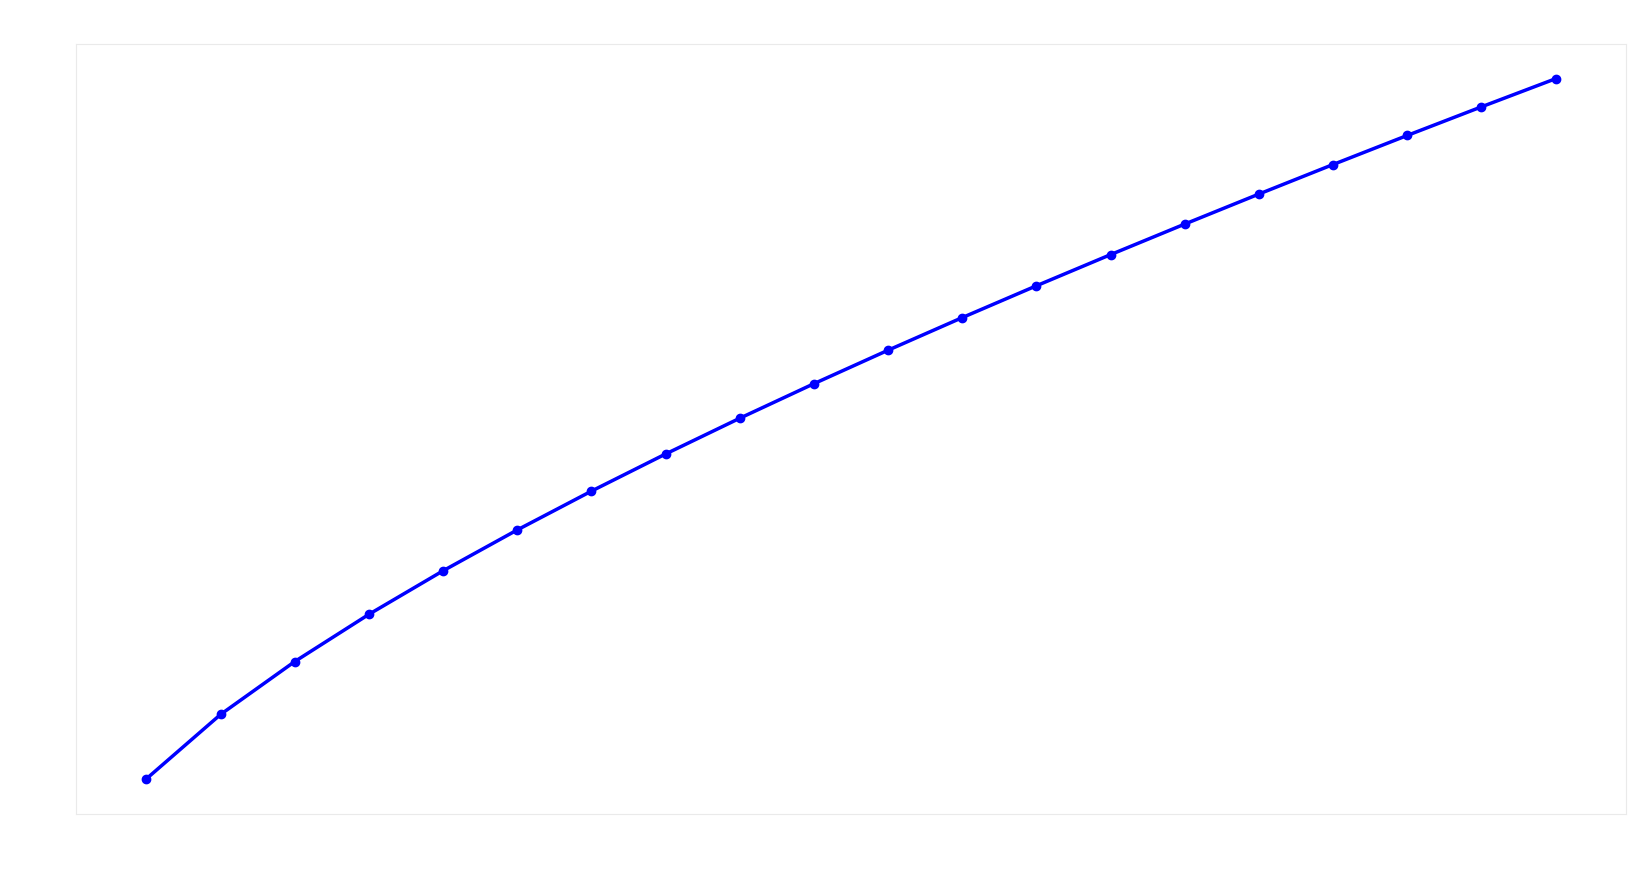

In [50]:
f, ax = plt.subplots(figsize=(20,10))
ax.plot([i for i in range(5,105,5)], [(j/EDX.size)*100 for j in nonzero_count_list],'o-b')
ax.set_title('Percentage of non-zero elements in the accumulated EDX dataset',fontsize=24)
ax.set_xlabel('Number of accumulated frames',fontsize=20)
ax.set_ylabel('%',fontsize=24)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

make_dark_presentation(f,text_color='white', line_width=2.5, transparent=True)
plt.savefig("/Users/aj/Desktop/WIPfigures/figure_sparseness.png", dpi=300, transparent=True)



WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)
WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)


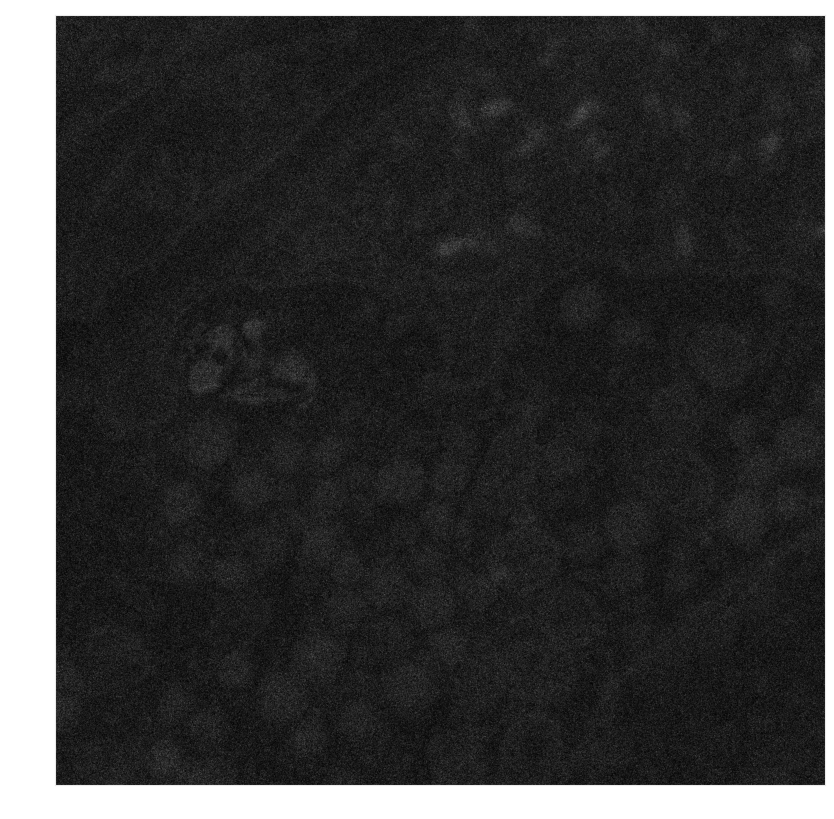

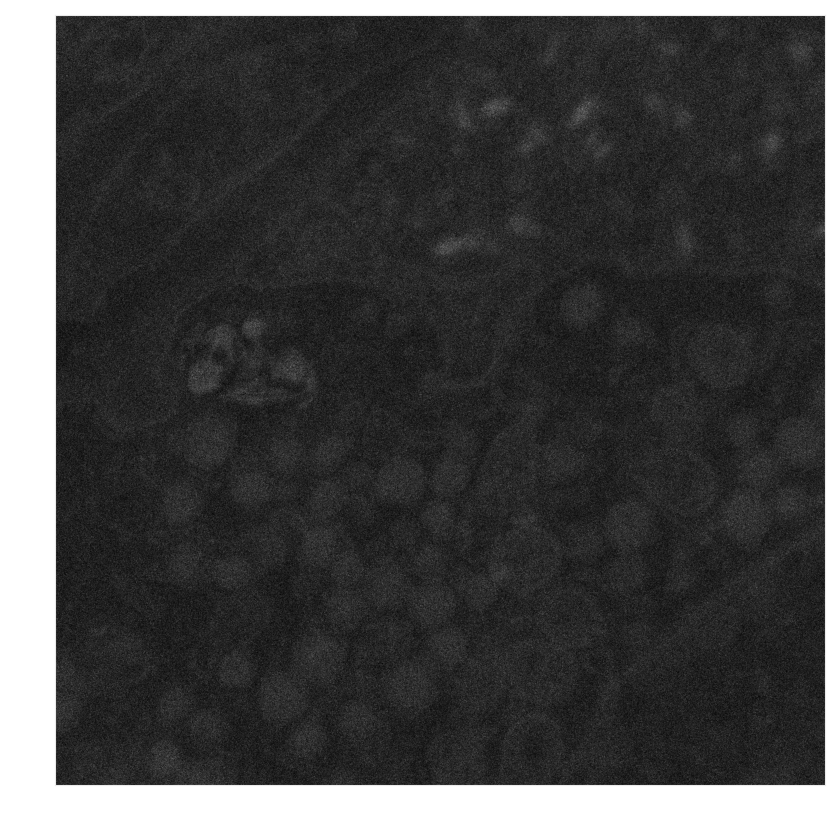

In [53]:
for frame in [40,80]:
    # load and preprocess
    EDX, haadf, xray_energies = load_EDX(file_path, first_frame=0, last_frame=frame, sum_frames=True, haadf_last_frame=False)
    tile_1 = EM_EDX(haadf[0,:,:], EDX ,xray_energies)
    tile_1.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
    tile_1.apply("binning", parameters={"dim": (2048, 2048, 250)})
    #tile_1.apply("MeanFilterEDX", parameters={"kernel_size": 3})

    f, ax = plt.subplots(figsize=(10,10))
    element = 28
    ax.imshow(tile_1.EDX[:,:,element],cmap='gray')
    
    make_dark_presentation(f,text_color='white', line_width=2.5, transparent=True)
    plt.savefig(f"/Users/aj/Desktop/WIPfigures/sparsness_frame_{frame:3d}_element_{element:3d}.png", dpi=300, transparent=True)
    
    